# Laboratorio 01 – Regresión Lineal
## Dataset: Poker Hand (UCI Machine Learning Repository)

**Objetivo:** Determinar los parámetros **θ (theta)** que mejor ajustan un modelo de
regresión lineal al dataset *Poker Hand*, empleando tres métodos distintos:

1. **Regresión Lineal Multivariable** mediante Descenso por Gradiente  
2. **Regresión Polinómica** (características de grado 2) mediante Descenso por Gradiente  
3. **Ecuación Normal** (solución analítica exacta)

Cada modelo incluye su función de costo J(θ), la curva de convergencia y la
evaluación sobre un conjunto de validación.

## 1. Importación de librerías

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

## 2. Carga y exploración del dataset

### Descripción del dataset

El dataset **Poker Hand** representa manos de póker de cinco cartas.
Cada fila es una mano descrita por **10 columnas**: palo (S) y rango (C) de cada carta.

| Columna | Descripción |
|---------|-------------|
| S1–S5   | Palo de la carta: 1=Corazones, 2=Picas, 3=Diamantes, 4=Tréboles |
| C1–C5   | Rango de la carta: 1=As, 2–10=Número, 11=J, 12=Q, 13=K |
| CLASS   | Tipo de mano: 0=Nada, 1=Par, 2=Doble Par, 3=Trío, 4=Escalera, 5=Color, 6=Full House, 7=Póker, 8=Escalera de Color, 9=Escalera Real |

Se aplica regresión lineal sobre las 10 características para predecir el valor numérico
de **CLASS** (0–9), de forma que el modelo aprenda una relación lineal entre las
características de las cartas y la clase de la mano.

In [4]:
# Nombres de columnas
nombres_col = ['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5']
columnas    = nombres_col + ['CLASS']

# Cargar el dataset (ajusta la ruta si es necesario)
df = pd.read_csv('/content/drive/MyDrive/IA/LAB03/poker-hand-training-true.data', header=None, names=columnas)

print("Primeras 10 filas del dataset:")
print(df.head(10))
print(f"\nDimensiones: {df.shape[0]} muestras × {df.shape[1]} columnas")

Primeras 10 filas del dataset:
   S1  C1  S2  C2  S3  C3  S4  C4  S5  C5  CLASS
0   1  10   1  11   1  13   1  12   1   1      9
1   2  11   2  13   2  10   2  12   2   1      9
2   3  12   3  11   3  13   3  10   3   1      9
3   4  10   4  11   4   1   4  13   4  12      9
4   4   1   4  13   4  12   4  11   4  10      9
5   1   2   1   4   1   5   1   3   1   6      8
6   1   9   1  12   1  10   1  11   1  13      8
7   2   1   2   2   2   3   2   4   2   5      8
8   3   5   3   6   3   9   3   7   3   8      8
9   4   1   4   4   4   2   4   3   4   5      8

Dimensiones: 25010 muestras × 11 columnas


In [5]:
# Separar características (X) y variable objetivo (y)
X_raw = df[nombres_col].values   # shape (m, 10)
y     = df['CLASS'].values        # shape (m,)
m     = y.size

print(f"X: {X_raw.shape}  |  y: {y.shape}  |  m = {m} ejemplos")
print(f"Clases presentes: {np.unique(y)}")
print(f"Distribución de clases:\n{pd.Series(y).value_counts().sort_index()}")

X: (25010, 10)  |  y: (25010,)  |  m = 25010 ejemplos
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Distribución de clases:
0    12493
1    10599
2     1206
3      513
4       93
5       54
6       36
7        6
8        5
9        5
Name: count, dtype: int64


## 3. Preprocesamiento

### 3.1 División entrenamiento / validación

Se reserva el **20 %** de los datos para validación y se usa el **80 %** para
entrenamiento.  Esto permite estimar qué tan bien generaliza cada modelo a datos
que no vio durante el ajuste de θ.

In [6]:
np.random.seed(42)
indices    = np.random.permutation(m)
tam_train  = int(0.8 * m)

idx_train  = indices[:tam_train]
idx_val    = indices[tam_train:]

X_train_raw = X_raw[idx_train]
y_train     = y[idx_train]
X_val_raw   = X_raw[idx_val]
y_val       = y[idx_val]

print(f"Entrenamiento : {X_train_raw.shape[0]} muestras")
print(f"Validación    : {X_val_raw.shape[0]} muestras")

Entrenamiento : 20008 muestras
Validación    : 5002 muestras


### 3.2 Normalización de características

Para que el Descenso por Gradiente converja de forma eficiente, se estandarizan
las características restando la media y dividiendo por la desviación estándar
(**z-score**).  Los parámetros de normalización se calculan **sólo** sobre el
conjunto de entrenamiento y se aplican también al conjunto de validación, evitando
filtración de información.

In [7]:
def normalizar(X_fit, X_apply=None):
    """
    Calcula mu y sigma en X_fit y los aplica a X_apply (o a X_fit si no se indica).
    Devuelve (X_norm, mu, sigma).
    """
    mu    = X_fit.mean(axis=0)
    sigma = X_fit.std(axis=0)
    sigma[sigma == 0] = 1          # evita división por cero
    target = X_apply if X_apply is not None else X_fit
    return (target - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = normalizar(X_train_raw)
X_val_norm,   _,  _     = normalizar(X_train_raw, X_val_raw)

print("Media (entrenamiento):  ", np.round(mu, 3))
print("Desv. estándar:         ", np.round(sigma, 3))

Media (entrenamiento):   [2.506 6.989 2.499 7.018 2.508 7.015 2.495 6.954 2.5   6.964]
Desv. estándar:          [1.118 3.752 1.121 3.764 1.12  3.743 1.117 3.747 1.115 3.736]


### 3.3 Agregar columna de unos (término de sesgo)

Se concatena una columna de unos a X para que el modelo incluya un término
independiente θ₀ (*bias*), de modo que la hipótesis queda:

$$h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n = X\,\theta$$

In [8]:
def agregar_unos(X):
    """Agrega una columna de 1s al inicio de la matriz X."""
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

X_train_m1 = agregar_unos(X_train_norm)   # shape (m_train, 11)
X_val_m1   = agregar_unos(X_val_norm)     # shape (m_val,   11)

print(f"X_train con sesgo: {X_train_m1.shape}")
print(f"X_val   con sesgo: {X_val_m1.shape}")

X_train con sesgo: (20008, 11)
X_val   con sesgo: (5002, 11)


## 4. Función de costo y Descenso por Gradiente

### Función de costo J(θ)



$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}\bigl(h_{\theta}(x^{(i)}) - y^{(i)}\bigr)^2
            = \frac{1}{2m}\|X\theta - y\|^2$$

### Descenso por Gradiente

Actualiza simultáneamente todos los parámetros θ en la dirección de mayor
descenso del gradiente de J:

$$\theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m}
\bigl(h_{\theta}(x^{(i)}) - y^{(i)}\bigr)\, x_j^{(i)}
\quad \forall\, j$$

En forma vectorial: $\theta := \theta - \dfrac{\alpha}{m}\, X^T(X\theta - y)$

In [9]:
def calcularCosto(X, y, theta):
    """
    Calcula el costo J(theta) = (1/2m) * ||X*theta - y||^2.
    """
    m     = y.size
    error = X @ theta - y
    return (1 / (2 * m)) * float(error @ error)


def descensoGradiente(X, y, theta, alpha, num_iter):
    """
    Ejecuta el Descenso por Gradiente durante `num_iter` iteraciones.
    Devuelve (theta_optimo, historial_de_costo).
    """
    m         = y.size
    J_history = np.zeros(num_iter)
    for i in range(num_iter):
        error     = X @ theta - y
        theta     = theta - (alpha / m) * (X.T @ error)
        J_history[i] = calcularCosto(X, y, theta)
    return theta, J_history


def metricas(y_real, y_pred, nombre="Modelo"):
    """Imprime MSE, RMSE, MAE y R² para evaluar el modelo."""
    mse  = np.mean((y_real - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_real - y_pred))
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - y_real.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    print(f"── {nombre} ──────────────────────────")
    print(f"  MSE  : {mse:.6f}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  R²   : {r2:.6f}")
    return mse, rmse, mae, r2

---
## Modelo 1 – Regresión Lineal Multivariable (Descenso por Gradiente)



$$h_{\theta}(x) = \theta_0 + \theta_1 S_1 + \theta_2 C_1 + \cdots + \theta_{10} C_5$$

El vector de parámetros $\theta \in \mathbb{R}^{n+1}$ se ajusta minimizando J(θ)
mediante Descenso por Gradiente.

### Parámetros del entrenamiento

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| α (alpha) | 0.1   | Tasa de aprendizaje |
| Iteraciones | 1 000 | Número de pasos del gradiente |
| θ inicial | **0** | Vector de ceros |

In [10]:
# ── Parámetros ──────────────────────────────────────────────────────────────
alpha_m1   = 0.1
num_iter_m1 = 1000
theta_init_m1 = np.zeros(X_train_m1.shape[1])

# ── Entrenamiento ─────────────────────────────────────────────────────────────
theta_m1, J_hist_m1 = descensoGradiente(
    X_train_m1, y_train, theta_init_m1, alpha_m1, num_iter_m1
)

print("Entrenamiento completado.")
print(f"Costo inicial  : {calcularCosto(X_train_m1, y_train, theta_init_m1):.6f}")
print(f"Costo final    : {J_hist_m1[-1]:.6f}")
print(f"Theta (primeros 5): {np.round(theta_m1[:5], 4)}")

Entrenamiento completado.
Costo inicial  : 0.506672
Costo final    : 0.312912
Theta (primeros 5): [ 0.6222  0.0074  0.0037  0.0018 -0.0035]


### Gráfico de convergencia del costo – Modelo 1

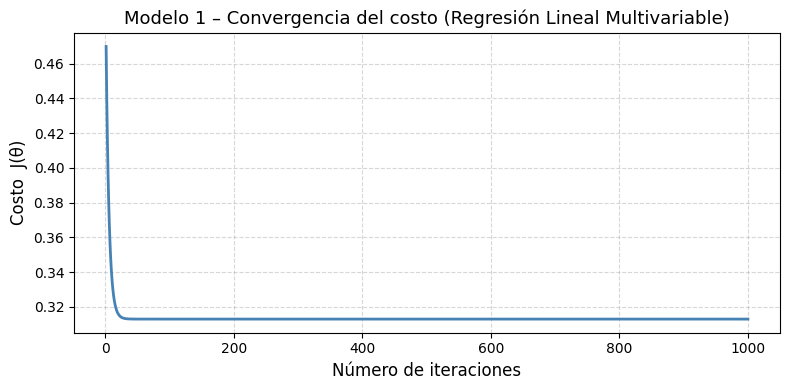

Reducción del costo: 0.4699 → 0.3129  (33.4 %)


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, num_iter_m1 + 1), J_hist_m1, color='steelblue', lw=2)
ax.set_xlabel('Número de iteraciones', fontsize=12)
ax.set_ylabel('Costo  J(θ)', fontsize=12)
ax.set_title('Modelo 1 – Convergencia del costo (Regresión Lineal Multivariable)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Reducción del costo: {J_hist_m1[0]:.4f} → {J_hist_m1[-1]:.4f}  "
      f"({(1 - J_hist_m1[-1]/J_hist_m1[0])*100:.1f} %)")

### Validación – Modelo 1


── Modelo 1 – Lineal Multivariable ──────────────────────────
  MSE  : 0.603927
  RMSE : 0.777128
  MAE  : 0.617128
  R²   : -0.002243


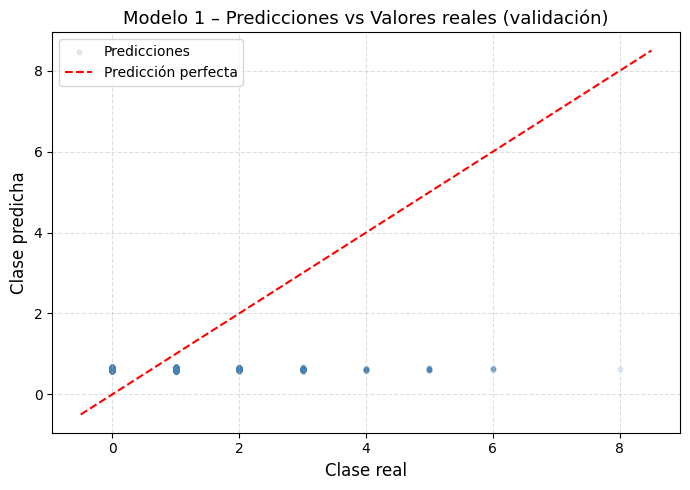

In [12]:
# Predicciones sobre el conjunto de validación
y_pred_m1 = X_val_m1 @ theta_m1

# Métricas
mse_m1, rmse_m1, mae_m1, r2_m1 = metricas(y_val, y_pred_m1, "Modelo 1 – Lineal Multivariable")

# Gráfico predicciones vs valores reales
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_val, y_pred_m1, alpha=0.15, s=10, color='steelblue', label='Predicciones')
lims = [y_val.min() - 0.5, y_val.max() + 0.5]
ax.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('Clase real', fontsize=12)
ax.set_ylabel('Clase predicha', fontsize=12)
ax.set_title('Modelo 1 – Predicciones vs Valores reales (validación)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Modelo 2 – Regresión Polinómica (grado 2)


### Parámetros del entrenamiento

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| α (alpha) | 0.05  | Tasa de aprendizaje |
| Iteraciones | 1 500 | Número de pasos del gradiente |
| θ inicial | **0** | Vector de ceros |
| Grado | 2 | Características cuadráticas |

In [13]:
def crear_caracteristicas_polinomicas(X, grado=2):
    """
    Agrega potencias de cada característica hasta `grado`.
    No incluye términos cruzados (interacción) para mantener la dimensión manejable.
    Retorna la matriz X aumentada CON la columna de unos al inicio.
    """
    cols = [np.ones(X.shape[0])]          # columna de unos (sesgo)
    for p in range(1, grado + 1):
        cols.append(X ** p)
    return np.column_stack(cols)


# Crear características polinómicas (grado 2) para entrenamiento y validación
X_train_m2 = crear_caracteristicas_polinomicas(X_train_norm, grado=2)
X_val_m2   = crear_caracteristicas_polinomicas(X_val_norm,   grado=2)

print(f"X_train polinómica (grado 2): {X_train_m2.shape}")
print(f"X_val   polinómica (grado 2): {X_val_m2.shape}")

X_train polinómica (grado 2): (20008, 21)
X_val   polinómica (grado 2): (5002, 21)


In [14]:
# ── Parámetros ──────────────────────────────────────────────────────────────
alpha_m2    = 0.05
num_iter_m2 = 1500
theta_init_m2 = np.zeros(X_train_m2.shape[1])

# ── Entrenamiento ─────────────────────────────────────────────────────────────
theta_m2, J_hist_m2 = descensoGradiente(
    X_train_m2, y_train, theta_init_m2, alpha_m2, num_iter_m2
)

print("Entrenamiento completado.")
print(f"Costo inicial  : {calcularCosto(X_train_m2, y_train, theta_init_m2):.6f}")
print(f"Costo final    : {J_hist_m2[-1]:.6f}")
print(f"Theta (primeros 5): {np.round(theta_m2[:5], 4)}")

Entrenamiento completado.
Costo inicial  : 0.506672
Costo final    : 0.312832
Theta (primeros 5): [ 0.6197  0.0073  0.0037  0.0018 -0.0034]


### Gráfico de convergencia del costo – Modelo 2


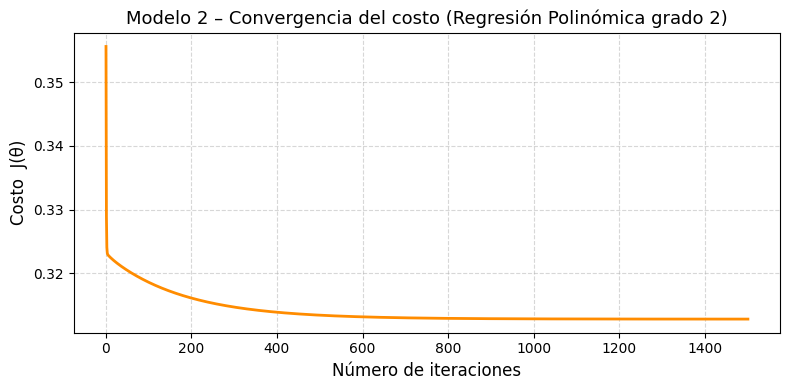

Reducción del costo: 0.3556 → 0.3128  (12.0 %)


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, num_iter_m2 + 1), J_hist_m2, color='darkorange', lw=2)
ax.set_xlabel('Número de iteraciones', fontsize=12)
ax.set_ylabel('Costo  J(θ)', fontsize=12)
ax.set_title('Modelo 2 – Convergencia del costo (Regresión Polinómica grado 2)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Reducción del costo: {J_hist_m2[0]:.4f} → {J_hist_m2[-1]:.4f}  "
      f"({(1 - J_hist_m2[-1]/J_hist_m2[0])*100:.1f} %)")

### Validación – Modelo 2

── Modelo 2 – Polinómica grado 2 ──────────────────────────
  MSE  : 0.604401
  RMSE : 0.777433
  MAE  : 0.617413
  R²   : -0.003030


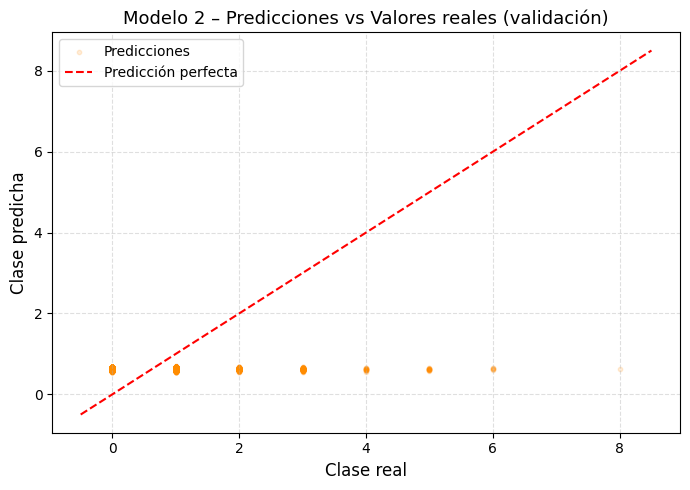

In [16]:
y_pred_m2 = X_val_m2 @ theta_m2

mse_m2, rmse_m2, mae_m2, r2_m2 = metricas(y_val, y_pred_m2, "Modelo 2 – Polinómica grado 2")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_val, y_pred_m2, alpha=0.15, s=10, color='darkorange', label='Predicciones')
lims = [y_val.min() - 0.5, y_val.max() + 0.5]
ax.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('Clase real', fontsize=12)
ax.set_ylabel('Clase predicha', fontsize=12)
ax.set_title('Modelo 2 – Predicciones vs Valores reales (validación)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Modelo 3 – Ecuación Normal

$$\theta = \left(X^T X\right)^{-1} X^T y$$


Para la Ecuación Normal se usan las características **lineales** normalizadas.

In [17]:
def ecuacion_normal(X, y):
    """
    Calcula theta mediante la Ecuación Normal:
    theta = (X^T X)^{-1} X^T y
    Se usa pseudo-inversa (np.linalg.pinv) para mayor estabilidad numérica.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ y


# ── Aplicar Ecuación Normal ──────────────────────────────────────────────────
theta_m3 = ecuacion_normal(X_train_m1, y_train)

print("Ecuación Normal resuelta.")
print(f"Theta (primeros 5): {np.round(theta_m3[:5], 4)}")
print(f"Costo sobre entrenamiento: {calcularCosto(X_train_m1, y_train, theta_m3):.6f}")

Ecuación Normal resuelta.
Theta (primeros 5): [ 0.6222  0.0074  0.0037  0.0018 -0.0035]
Costo sobre entrenamiento: 0.312912


### Gráfico de costo – Modelo 3

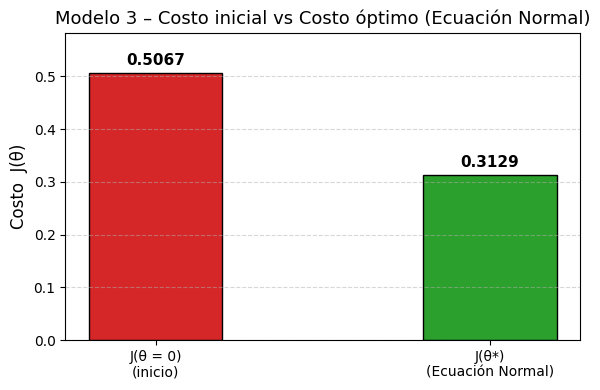

Costo inicial  : 0.506672
Costo óptimo   : 0.312912
Mejora         : 38.2 %


In [18]:
theta_cero_m3 = np.zeros(X_train_m1.shape[1])
J_inicial_m3  = calcularCosto(X_train_m1, y_train, theta_cero_m3)
J_optimo_m3   = calcularCosto(X_train_m1, y_train, theta_m3)

etiquetas  = ['J(θ = 0)\n(inicio)', 'J(θ*)\n(Ecuación Normal)']
valores    = [J_inicial_m3, J_optimo_m3]
colores    = ['#d62728', '#2ca02c']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(etiquetas, valores, color=colores, width=0.4, edgecolor='black')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Costo  J(θ)', fontsize=12)
ax.set_title('Modelo 3 – Costo inicial vs Costo óptimo (Ecuación Normal)', fontsize=13)
ax.set_ylim(0, J_inicial_m3 * 1.15)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Costo inicial  : {J_inicial_m3:.6f}")
print(f"Costo óptimo   : {J_optimo_m3:.6f}")
print(f"Mejora         : {(1 - J_optimo_m3/J_inicial_m3)*100:.1f} %")

### Validación – Modelo 3

── Modelo 3 – Ecuación Normal ──────────────────────────
  MSE  : 0.603927
  RMSE : 0.777128
  MAE  : 0.617128
  R²   : -0.002243


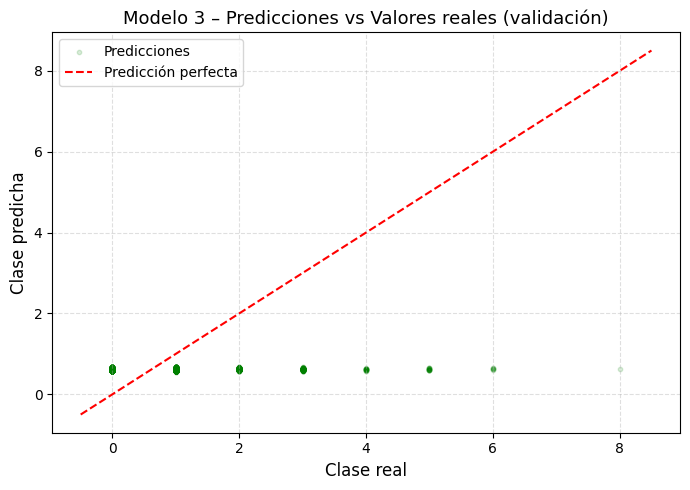

In [19]:
y_pred_m3 = X_val_m1 @ theta_m3

mse_m3, rmse_m3, mae_m3, r2_m3 = metricas(y_val, y_pred_m3, "Modelo 3 – Ecuación Normal")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_val, y_pred_m3, alpha=0.15, s=10, color='green', label='Predicciones')
lims = [y_val.min() - 0.5, y_val.max() + 0.5]
ax.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('Clase real', fontsize=12)
ax.set_ylabel('Clase predicha', fontsize=12)
ax.set_title('Modelo 3 – Predicciones vs Valores reales (validación)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 5. Comparación de los tres modelos

In [20]:
# ── Tabla comparativa ───────────────────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo': [
        '1 – Lineal Multivariable (GD)',
        '2 – Polinómica grado 2 (GD)',
        '3 – Ecuación Normal'
    ],
    'MSE'  : [mse_m1,  mse_m2,  mse_m3],
    'RMSE' : [rmse_m1, rmse_m2, rmse_m3],
    'MAE'  : [mae_m1,  mae_m2,  mae_m3],
    'R²'   : [r2_m1,   r2_m2,   r2_m3],
})
resultados = resultados.set_index('Modelo')
print(resultados.round(6).to_string())

                                    MSE      RMSE       MAE        R²
Modelo                                                               
1 – Lineal Multivariable (GD)  0.603927  0.777128  0.617128 -0.002243
2 – Polinómica grado 2 (GD)    0.604401  0.777433  0.617413 -0.003030
3 – Ecuación Normal            0.603927  0.777128  0.617128 -0.002243


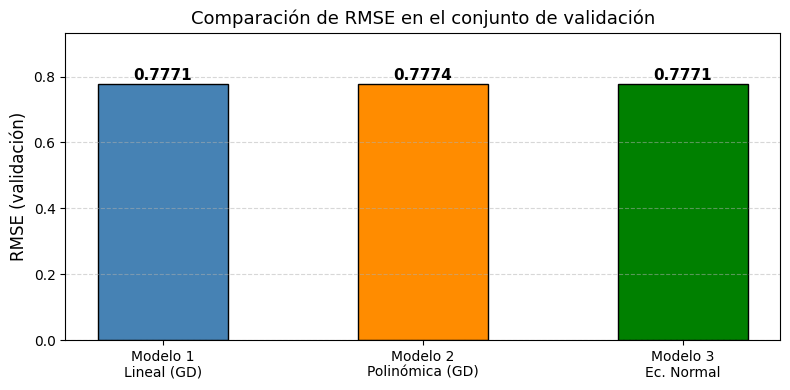

In [21]:
# ── Gráfico comparativo de RMSE ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
modelos = ['Modelo 1\nLineal (GD)', 'Modelo 2\nPolinómica (GD)', 'Modelo 3\nEc. Normal']
rmses   = [rmse_m1, rmse_m2, rmse_m3]
colores = ['steelblue', 'darkorange', 'green']

bars = ax.bar(modelos, rmses, color=colores, edgecolor='black', width=0.5)
for bar, v in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('RMSE (validación)', fontsize=12)
ax.set_title('Comparación de RMSE en el conjunto de validación', fontsize=13)
ax.set_ylim(0, max(rmses) * 1.2)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_885/1686536969.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


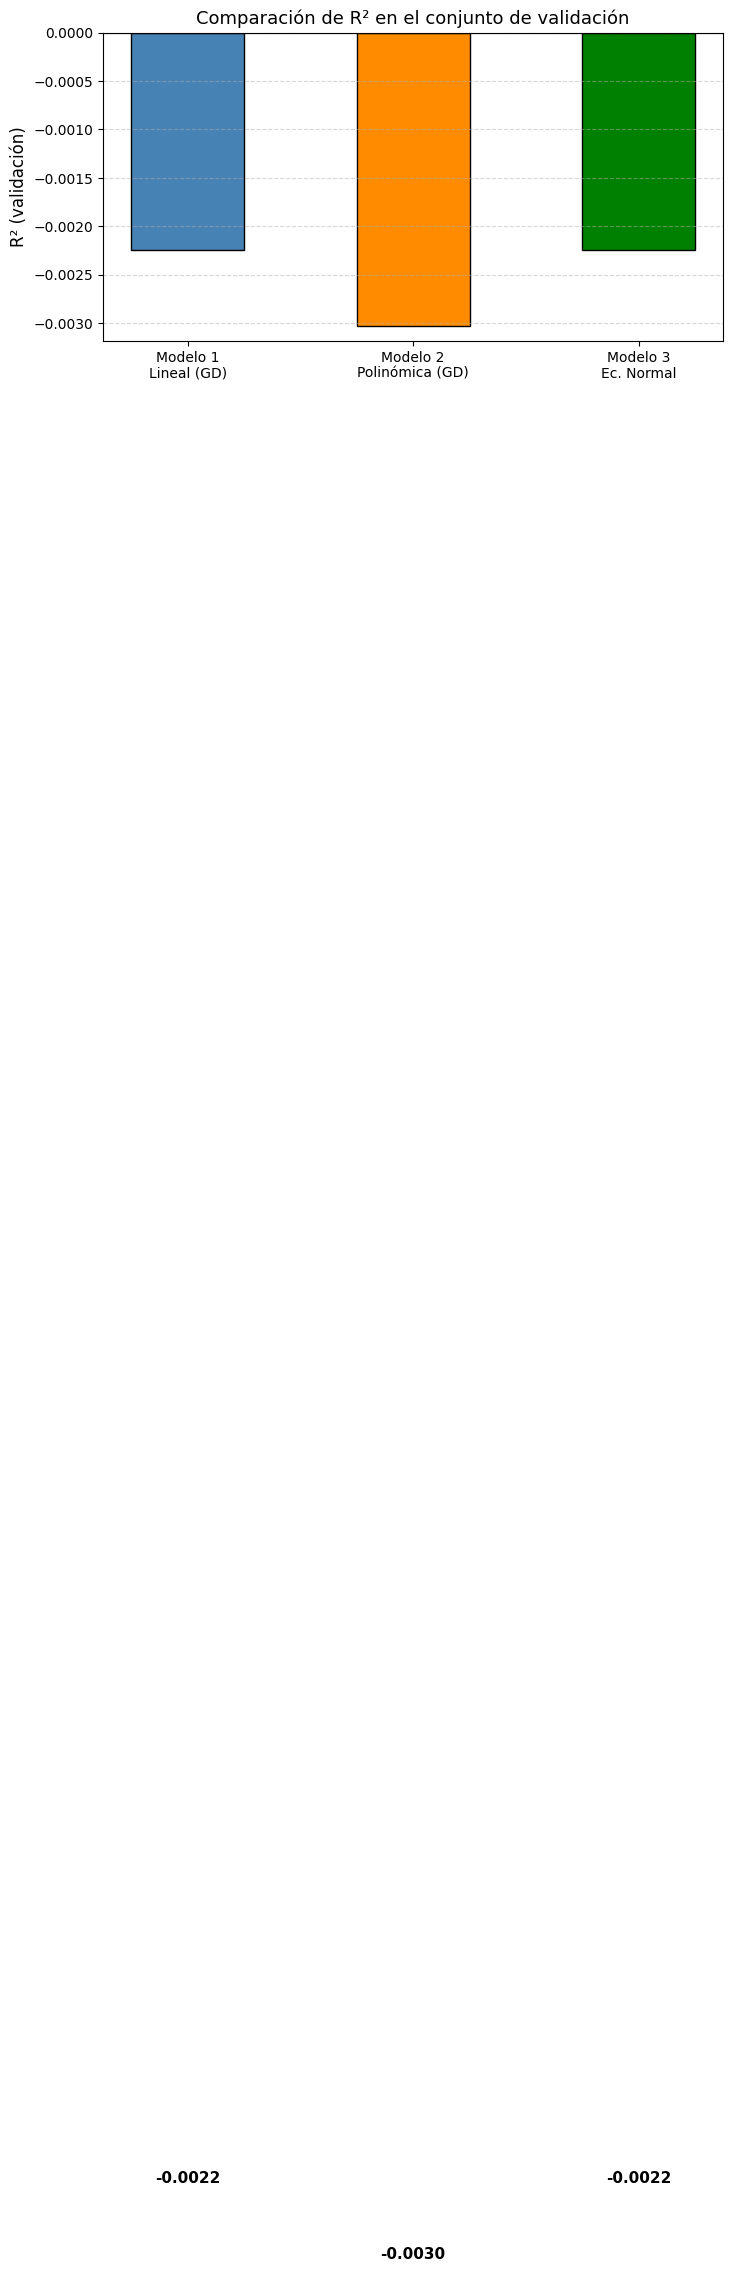

In [22]:
# ── Gráfico comparativo de R² ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
r2s = [r2_m1, r2_m2, r2_m3]

bars = ax.bar(modelos, r2s, color=colores, edgecolor='black', width=0.5)
for bar, v in zip(bars, r2s):
    offset = 0.005 if v >= 0 else -0.02
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('R² (validación)', fontsize=12)
ax.set_title('Comparación de R² en el conjunto de validación', fontsize=13)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación de resultados

| Métrica | Interpretación |
|---------|---------------|
| **MSE / RMSE** | Error cuadrático medio / su raíz. Penaliza errores grandes. Menor es mejor. |
| **MAE** | Error absoluto medio. Más robusto a valores atípicos. Menor es mejor. |
| **R²** | Coeficiente de determinación. Fracción de varianza explicada. Más cercano a 1 es mejor. |

**Observaciones:**

- El **Modelo 3 (Ecuación Normal)** y el **Modelo 1 (Descenso por Gradiente lineal)**
  deben producir métricas muy similares, ya que ambos minimizan la misma función de costo
  lineal.  La pequeña diferencia se debe a que el Descenso por Gradiente puede no haber
  convergido exactamente al óptimo con el número de iteraciones elegido.

- El **Modelo 2 (Polinómica)** introduce términos cuadráticos, dando al modelo mayor
  capacidad para capturar relaciones no lineales entre las cartas.  Si el R² mejora
  respecto a los modelos lineales, confirma que existen patrones cuadráticos en el dataset.